# 🎱 Greek Joker Lottery — Statistical Fairness Analysis

Statistical investigation of the Greek Joker lottery using historical draw data from OPAP S.A. (1997–2024). The goal is to determine whether the draw outcomes are consistent with a fair, uniform random process.

---

## 1 · Imports

In [1]:
import pandas as pd
import numpy as np
import glob
import os

## 2 · Data Ingestion

Load all yearly `.xlsx` files, strip formatting rows and index columns, rename number columns, and tag each row with its source year.

In [2]:
path = r'C:\Users\makis\Desktop\LotteryExcel'
all_files=glob.glob(os.path.join(path,"*xlsx"))

df_list=[]
cols=[0,1]

for file in all_files:
    sheets = pd.read_excel(file, sheet_name=None)  # load all sheets as dict

    for sheet_name, df in sheets.items():
        df = df.drop(df.columns[cols], axis=1)
        df = df.iloc[:, :7]
        df = df.iloc[3:]
        df.rename(columns={
            'Unnamed: 2': 'n1',
            'Unnamed: 3': 'n2',
            'Unnamed: 4': 'n3',
            'Unnamed: 5': 'n4',
            'Unnamed: 6': 'n5',
            'Unnamed: 7': 'joker',
            'Unnamed: 8': 'joker'
        }, inplace=True)
        df.iloc[:, -1] = pd.to_numeric(df.iloc[:, -1], errors='coerce')
        if df.isnull().any().any():
            df = df.dropna(axis=1)
        elif (df.iloc[:, -1] > 20).any():
            df = df.iloc[:, :-1]

        year = int(os.path.basename(file).replace('Joker_', '').replace('.xlsx', ''))
        df['year'] = year

        df_list.append(df)

c:\Users\makis\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\makis\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


## 3 · Concatenate & Type-cast

Merge all yearly DataFrames into one, cast number columns to `int`, and assign a global `draw_id`.

In [3]:
df = pd.concat(df_list, ignore_index=True)
main_cols = ['n1', 'n2', 'n3', 'n4', 'n5']
df[main_cols] = df[main_cols].astype(int)
df['joker']   = df['joker'].astype(int)

In [4]:
df = df.sort_values('year').reset_index(drop=True)
df['draw_id'] = df.index + 1

## 4 · Exploratory Data Analysis

Quick sanity checks: row counts, year range, draws per year, and value ranges.

In [5]:
print(df.columns.tolist()) 
print(df.head())

['n1', 'n2', 'n3', 'n4', 'n5', 'joker', 'year', 'draw_id']
   n1  n2  n3  n4  n5  joker  year  draw_id
0  13  34  38  17   4     12  1997        1
1  32  18  12   5  20      2  1997        2
2  10  31  11  44  36      8  1997        3
3  18   6  28  23  35      5  1997        4
4   5  37  42  11   6      7  1997        5


In [6]:
print(df.tail())

      n1  n2  n3  n4  n5  joker  year  draw_id
3223  30  26   4  43  15      9  2026     3224
3224  26  16  33  12  30     20  2026     3225
3225  25  44  32  26  13     11  2026     3226
3226   2  18  21  20   9      3  2026     3227
3227   6   4   3  36  33     13  2026     3228


In [7]:
print(f"Total draws: {len(df)}")
print(f"Years: {df['year'].min()} → {df['year'].max()}")
print(f"Draws per year:\n{df['year'].value_counts().sort_index()}")
print(df.head())

Total draws: 3228
Years: 1997 → 2026
Draws per year:
year
1997     14
1998    103
1999    103
2000    104
2001    104
2002    105
2003    103
2004    103
2005    104
2006    103
2007    102
2008    101
2009    103
2010    103
2011    103
2012    103
2013    103
2014    103
2015    104
2016    103
2017    104
2018    103
2019    103
2020    143
2021    155
2022    154
2023    155
2024    156
2025    155
2026     26
Name: count, dtype: int64
   n1  n2  n3  n4  n5  joker  year  draw_id
0  13  34  38  17   4     12  1997        1
1  32  18  12   5  20      2  1997        2
2  10  31  11  44  36      8  1997        3
3  18   6  28  23  35      5  1997        4
4   5  37  42  11   6      7  1997        5


In [8]:
print(f"\nAny nulls: {df.isnull().sum().sum()}")
print(f"\nMain numbers range: {df[['n1','n2','n3','n4','n5']].min().min()} – {df[['n1','n2','n3','n4','n5']].max().max()}")
print(f"Joker range: {df['joker'].min()} – {df['joker'].max()}")


Any nulls: 0

Main numbers range: 1 – 45
Joker range: 1 – 20


## 5 · Additional Imports for Analysis

In [9]:
import matplotlib.pyplot as plt
import scipy.stats as stats

## 6 · Uniformity Test — Main Numbers (χ² Goodness of Fit)

Under a fair lottery each of the 45 main numbers should appear with equal probability. We flatten all draws into a single frequency vector and test it against a uniform expectation.

In [10]:
main_numbers = df[['n1','n2','n3','n4','n5']].values.flatten()
n_draws = len(df)
n_obs = len(main_numbers)
print(n_draws)
print(n_obs)

3228
16140


In [11]:
observed = np.array([np.sum(main_numbers == i) for i in range(1, 46)])
expected_freq = n_obs / 45  # uniform expectation
expected = np.full(45, expected_freq)

print(f"Total number observations: {n_obs}")
print(f"Expected frequency per number: {expected_freq:.2f}")
print(f"Observed min: {observed.min()} | max: {observed.max()}")

Total number observations: 16140
Expected frequency per number: 358.67
Observed min: 329 | max: 390


In [12]:
chi2, p_value = stats.chisquare(observed, expected)
print(f"\nChi-Square statistic: {chi2:.4f}")
print(f"p-value:              {p_value:.4f}")
print(f"Degrees of freedom:   44")
print(f"Critical value (p=0.05): 60.48")
print(f"\nVerdict: {'❌ REJECT uniformity — bias detected' if p_value < 0.05 else '✅ FAIL to reject — consistent with random'}")


Chi-Square statistic: 27.8922
p-value:              0.9722
Degrees of freedom:   44
Critical value (p=0.05): 60.48

Verdict: ✅ FAIL to reject — consistent with random


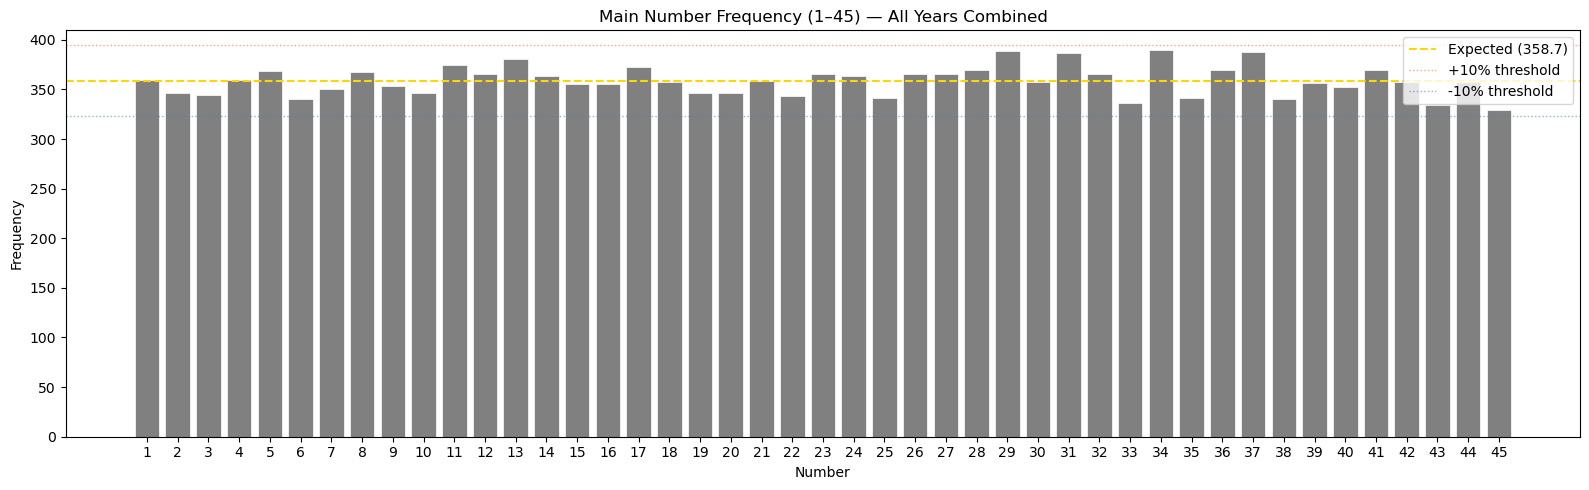

In [13]:
plt.figure(figsize=(16, 5))
colors = ['tomato' if o > expected_freq * 1.1 else 'steelblue' if o < expected_freq * 0.9 else 'gray' 
          for o in observed]
plt.bar(range(1, 46), observed, color=colors, edgecolor='white', linewidth=0.5)
plt.axhline(expected_freq, color='gold', linestyle='--', linewidth=1.5, label=f'Expected ({expected_freq:.1f})')
plt.axhline(expected_freq * 1.1, color='tomato', linestyle=':', linewidth=1, alpha=0.6, label='+10% threshold')
plt.axhline(expected_freq * 0.9, color='steelblue', linestyle=':', linewidth=1, alpha=0.6, label='-10% threshold')
plt.xlabel('Number')
plt.ylabel('Frequency')
plt.title('Main Number Frequency (1–45) — All Years Combined')
plt.xticks(range(1, 46))
plt.legend()
plt.tight_layout()
plt.show()

## 7 · Uniformity Test — Joker Number (1–20)

Same χ² test applied to the Joker ball, which is drawn independently from a pool of 20.

In [14]:
joker_numbers = df['joker'].values
joker_obs = np.array([np.sum(joker_numbers == i) for i in range(1, 21)])
joker_expected_freq = len(joker_numbers) / 20
joker_expected = np.full(20, joker_expected_freq)

In [15]:
chi2_j, p_value_j = stats.chisquare(joker_obs, joker_expected)
print(f"\nJoker Chi-Square statistic: {chi2_j:.4f}")
print(f"p-value:                    {p_value_j:.4f}")
print(f"Degrees of freedom:         19")
print(f"Critical value (p=0.05):    30.14")
print(f"\nVerdict: {'❌ REJECT uniformity — bias detected' if p_value_j < 0.05 else '✅ FAIL to reject — consistent with random'}")


Joker Chi-Square statistic: 10.6617
p-value:                    0.9347
Degrees of freedom:         19
Critical value (p=0.05):    30.14

Verdict: ✅ FAIL to reject — consistent with random


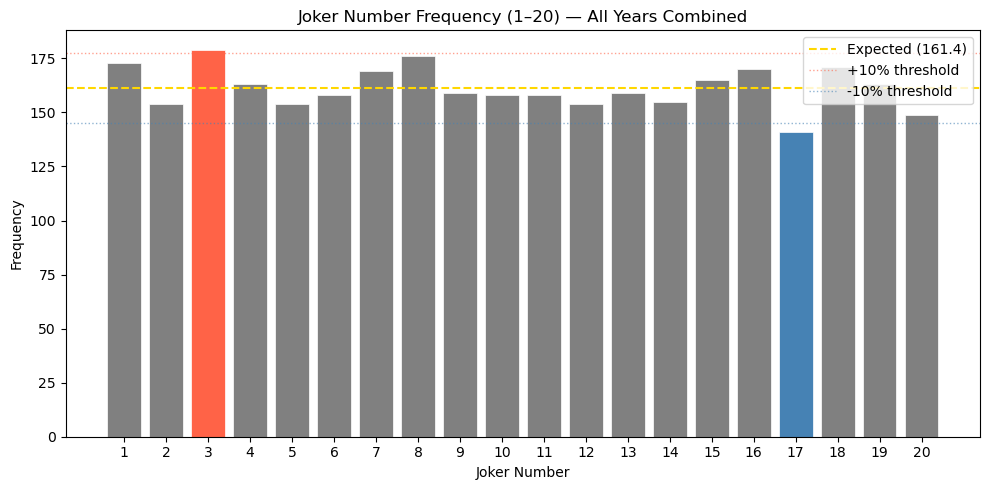

In [16]:
plt.figure(figsize=(10, 5))
colors_j = ['tomato' if o > joker_expected_freq * 1.1 else 'steelblue' if o < joker_expected_freq * 0.9 else 'gray'
            for o in joker_obs]
plt.bar(range(1, 21), joker_obs, color=colors_j, edgecolor='white', linewidth=0.5)
plt.axhline(joker_expected_freq, color='gold', linestyle='--', linewidth=1.5, label=f'Expected ({joker_expected_freq:.1f})')
plt.axhline(joker_expected_freq * 1.1, color='tomato', linestyle=':', linewidth=1, alpha=0.6, label='+10% threshold')
plt.axhline(joker_expected_freq * 0.9, color='steelblue', linestyle=':', linewidth=1, alpha=0.6, label='-10% threshold')
plt.xlabel('Joker Number')
plt.ylabel('Frequency')
plt.title('Joker Number Frequency (1–20) — All Years Combined')
plt.xticks(range(1, 21))
plt.legend()
plt.tight_layout()
plt.show()

## 8 · Year-by-Year χ² Analysis

Testing each year independently reveals whether any single year deviates from uniformity. We then apply a **Bonferroni correction** to control the family-wise error rate across ~30 simultaneous tests.

In [17]:
years = sorted(df['year'].unique())
chi2_by_year = []

for year in years:
    df_year = df[df['year'] == year]
    nums = df_year[['n1','n2','n3','n4','n5']].values.flatten()
    obs = np.array([np.sum(nums == i) for i in range(1, 46)])
    exp = np.full(45, len(nums) / 45)
    chi2_y, p_y = stats.chisquare(obs, exp)
    chi2_by_year.append({'year': year, 'chi2': chi2_y, 'p_value': p_y, 'n_draws': len(df_year)})

results_year = pd.DataFrame(chi2_by_year)
print(results_year.to_string(index=False))

 year      chi2  p_value  n_draws
 1997 43.142857 0.508263       14
 1998 53.223301 0.160640      103
 1999 37.844660 0.731555      103
 2000 67.769231 0.012185      104
 2001 30.903846 0.932149      104
 2002 46.971429 0.351733      105
 2003 30.330097 0.941800      103
 2004 31.029126 0.929903      103
 2005 44.923077 0.433000      104
 2006 36.796117 0.771020      103
 2007 53.823529 0.147326      102
 2008 39.722772 0.655383      101
 2009 47.106796 0.346631      103
 2010 43.087379 0.510651      103
 2011 44.485437 0.451197      103
 2012 32.776699 0.893219      103
 2013 46.407767 0.373364      103
 2014 25.786408 0.987048      103
 2015 38.519231 0.704896      104
 2016 39.592233 0.660853      103
 2017 38.000000 0.725497      104
 2018 48.155340 0.308418      103
 2019 35.398058 0.819184      103
 2020 49.370629 0.267235      143
 2021 37.961290 0.727011      155
 2022 40.467532 0.623813      154
 2023 48.645161 0.291403      155
 2024 36.807692 0.770599      156
 2025 24.83871

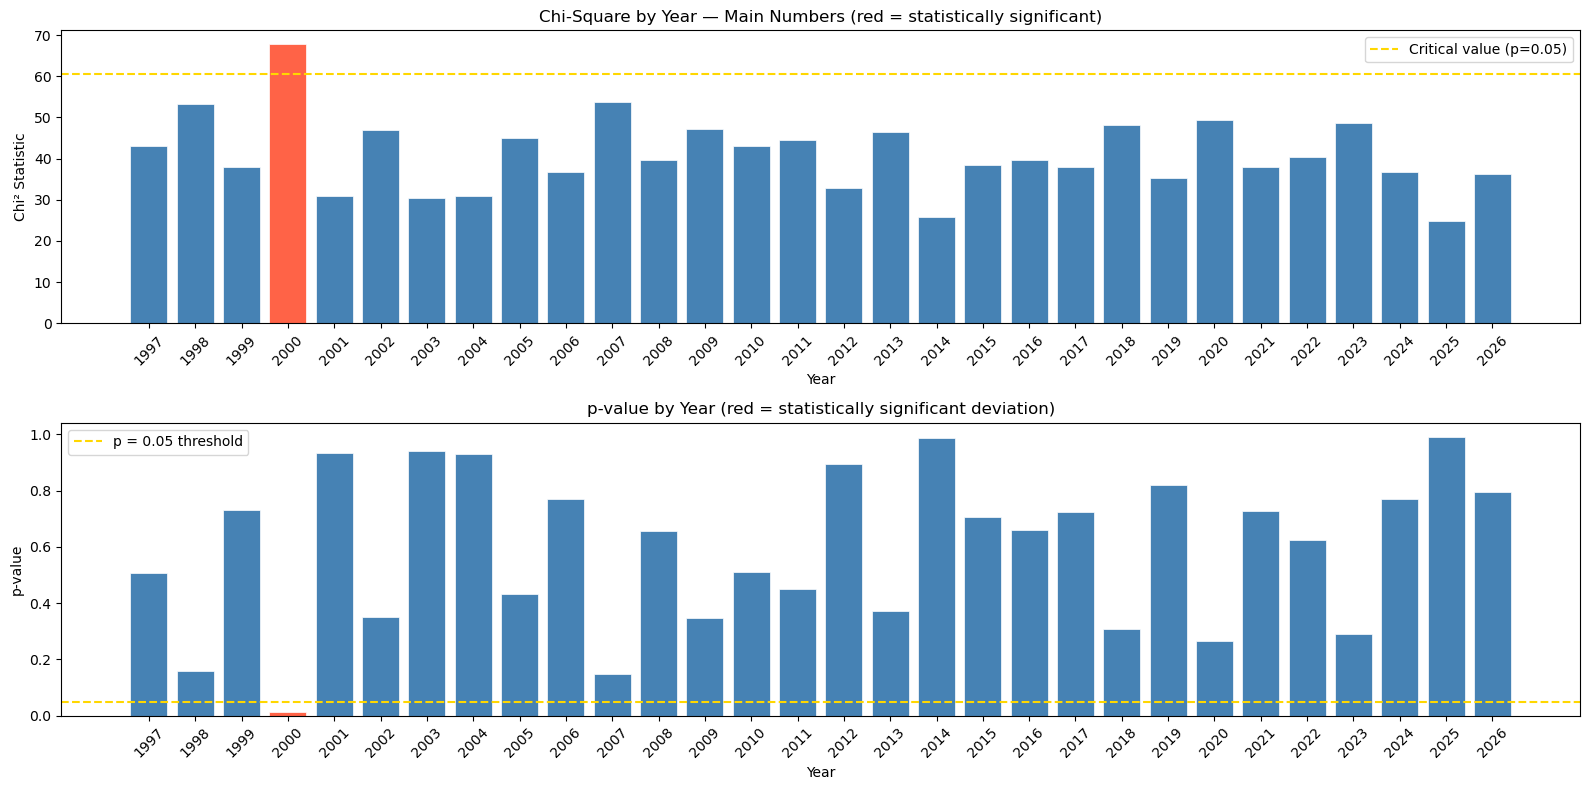

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
axes[0].bar(results_year['year'], results_year['chi2'],
            color=['tomato' if p < 0.05 else 'steelblue' for p in results_year['p_value']],
            edgecolor='white', linewidth=0.5)
axes[0].axhline(60.48, color='gold', linestyle='--', linewidth=1.5, label='Critical value (p=0.05)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Chi² Statistic')
axes[0].set_title('Chi-Square by Year — Main Numbers (red = statistically significant)')
axes[0].legend()
axes[0].set_xticks(years)
axes[0].tick_params(axis='x', rotation=45)



axes[1].bar(results_year['year'], results_year['p_value'],
            color=['tomato' if p < 0.05 else 'steelblue' for p in results_year['p_value']],
            edgecolor='white', linewidth=0.5)
axes[1].axhline(0.05, color='gold', linestyle='--', linewidth=1.5, label='p = 0.05 threshold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('p-value')
axes[1].set_title('p-value by Year (red = statistically significant deviation)')
axes[1].legend()
axes[1].set_xticks(years)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 8.1 · Drill-down: Year 2000

The only year flagged before correction is examined more closely to identify which numbers drove the deviation.

Year 2000 — Top deviating numbers:
 number  observed  expected  deviation  pct_deviation
     18        20 11.555556   8.444444           73.1
     37        20 11.555556   8.444444           73.1
     34        18 11.555556   6.444444           55.8
     40        18 11.555556   6.444444           55.8
     32        17 11.555556   5.444444           47.1
     13        16 11.555556   4.444444           38.5
     29        16 11.555556   4.444444           38.5
     21        16 11.555556   4.444444           38.5
     27        15 11.555556   3.444444           29.8
     17        14 11.555556   2.444444           21.2

Bottom deviating numbers:
 number  observed  expected  deviation  pct_deviation
      6         8 11.555556  -3.555556          -30.8
     42         8 11.555556  -3.555556          -30.8
     41         7 11.555556  -4.555556          -39.4
     45         7 11.555556  -4.555556          -39.4
     15         6 11.555556  -5.555556          -48.1
     43         6 11

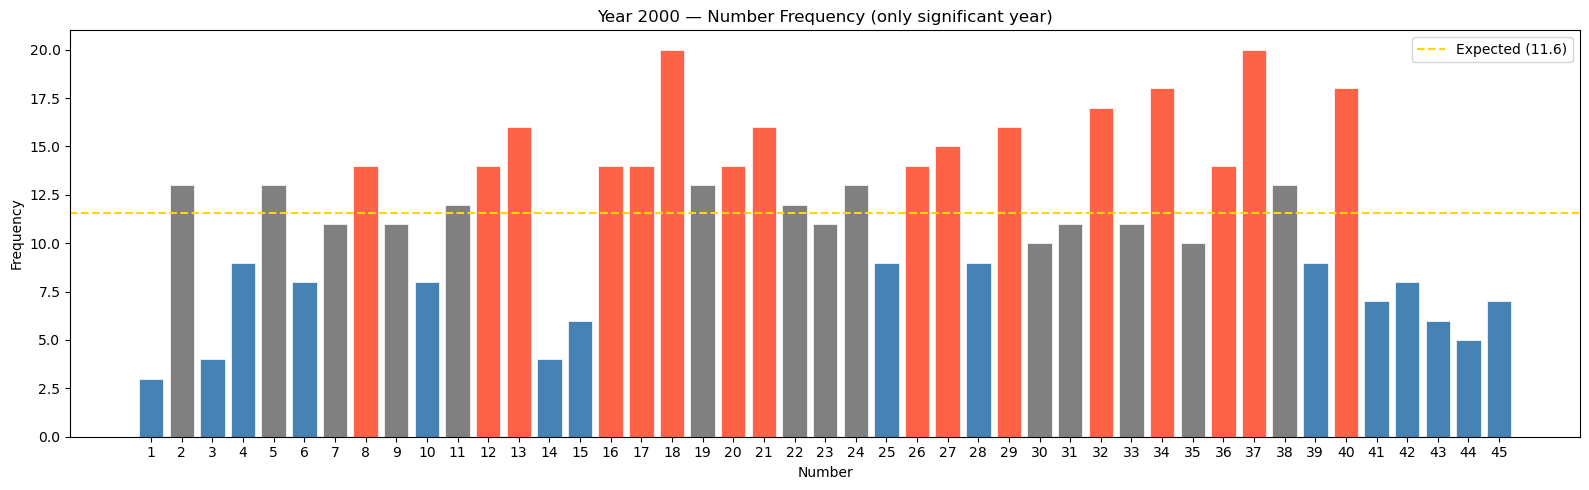

In [19]:
# ── Investigate year 2000 ─────────────────────────────────────────
df_2000 = df[df['year'] == 2000]
nums_2000 = df_2000[['n1','n2','n3','n4','n5']].values.flatten()
obs_2000 = np.array([np.sum(nums_2000 == i) for i in range(1, 46)])
expected_2000 = len(nums_2000) / 45

# which numbers are driving the deviation?
deviation = pd.DataFrame({
    'number': range(1, 46),
    'observed': obs_2000,
    'expected': expected_2000,
    'deviation': obs_2000 - expected_2000,
    'pct_deviation': ((obs_2000 - expected_2000) / expected_2000 * 100).round(1)
}).sort_values('deviation', ascending=False)

print("Year 2000 — Top deviating numbers:")
print(deviation.head(10).to_string(index=False))
print("\nBottom deviating numbers:")
print(deviation.tail(10).to_string(index=False))

# ── Plot 2000 vs overall expected ────────────────────────────────
plt.figure(figsize=(16, 5))
colors_2000 = ['tomato' if o > expected_2000 * 1.2 else 'steelblue' if o < expected_2000 * 0.8 else 'gray'
               for o in obs_2000]
plt.bar(range(1, 46), obs_2000, color=colors_2000, edgecolor='white', linewidth=0.5)
plt.axhline(expected_2000, color='gold', linestyle='--', linewidth=1.5, label=f'Expected ({expected_2000:.1f})')
plt.xlabel('Number')
plt.ylabel('Frequency')
plt.title('Year 2000 — Number Frequency (only significant year)')
plt.xticks(range(1, 46))
plt.legend()
plt.tight_layout()
plt.show()

### 8.2 · Bonferroni Correction

After correcting for multiple comparisons, we check whether any year's result remains statistically significant.

In [20]:
from statsmodels.stats.multitest import multipletests

# ── Bonferroni correction across all 30 years ─────────────────────
p_values = results_year['p_value'].values
reject, p_corrected, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

results_year['p_corrected'] = p_corrected
results_year['reject_H0'] = reject

print("After Bonferroni correction:")
print(results_year[['year', 'chi2', 'p_value', 'p_corrected', 'reject_H0']].to_string(index=False))
print(f"\nYears rejecting H0 after correction: {results_year[results_year['reject_H0']]['year'].tolist()}")

After Bonferroni correction:
 year      chi2  p_value  p_corrected  reject_H0
 1997 43.142857 0.508263      1.00000      False
 1998 53.223301 0.160640      1.00000      False
 1999 37.844660 0.731555      1.00000      False
 2000 67.769231 0.012185      0.36556      False
 2001 30.903846 0.932149      1.00000      False
 2002 46.971429 0.351733      1.00000      False
 2003 30.330097 0.941800      1.00000      False
 2004 31.029126 0.929903      1.00000      False
 2005 44.923077 0.433000      1.00000      False
 2006 36.796117 0.771020      1.00000      False
 2007 53.823529 0.147326      1.00000      False
 2008 39.722772 0.655383      1.00000      False
 2009 47.106796 0.346631      1.00000      False
 2010 43.087379 0.510651      1.00000      False
 2011 44.485437 0.451197      1.00000      False
 2012 32.776699 0.893219      1.00000      False
 2013 46.407767 0.373364      1.00000      False
 2014 25.786408 0.987048      1.00000      False
 2015 38.519231 0.704896      1.00000   

## 9 · Draw Sum Distribution (KS Test)

If five numbers are drawn independently and uniformly from 1–45, their sum follows a known theoretical distribution. We simulate 100,000 fair draws and compare with the observed sums using a Kolmogorov-Smirnov test.

KS Statistic: 0.0063
p-value:      0.9996

Verdict: ✅ Observed sums consistent with random draws


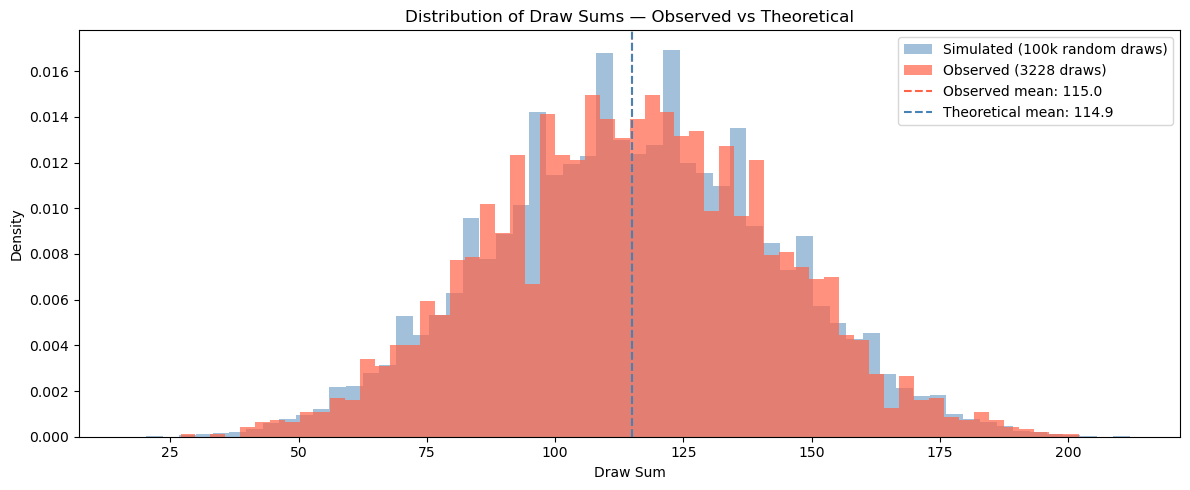

In [21]:
#now we will test whether the 5 numbers within a draw are independent of each other

# ── Sum distribution KS test ──────────────────────────────────────
# theoretical distribution of sum of 5 numbers drawn without 
# replacement from 1-45 has mean=115, we simulate it
np.random.seed(42)
n_simulations = 100_000
simulated_sums = np.array([
    np.random.choice(range(1, 46), size=5, replace=False).sum()
    for _ in range(n_simulations)
])

observed_sums = df[['n1','n2','n3','n4','n5']].sum(axis=1).values

# KS test
ks_stat, ks_p = stats.ks_2samp(observed_sums, simulated_sums)
print(f"KS Statistic: {ks_stat:.4f}")
print(f"p-value:      {ks_p:.4f}")
print(f"\nVerdict: {'❌ Distributions differ significantly' if ks_p < 0.05 else '✅ Observed sums consistent with random draws'}")

# ── Plot ──────────────────────────────────────────────────────────
plt.figure(figsize=(12, 5))
plt.hist(simulated_sums, bins=60, alpha=0.5, color='steelblue', 
         density=True, label='Simulated (100k random draws)')
plt.hist(observed_sums, bins=60, alpha=0.7, color='tomato', 
         density=True, label=f'Observed ({len(observed_sums)} draws)')
plt.axvline(observed_sums.mean(), color='tomato', linestyle='--', linewidth=1.5, 
            label=f'Observed mean: {observed_sums.mean():.1f}')
plt.axvline(simulated_sums.mean(), color='steelblue', linestyle='--', linewidth=1.5, 
            label=f'Theoretical mean: {simulated_sums.mean():.1f}')
plt.xlabel('Draw Sum')
plt.ylabel('Density')
plt.title('Distribution of Draw Sums — Observed vs Theoretical')
plt.legend()
plt.tight_layout()
plt.show()

## 10 · Odd/Even & High/Low Balance

Each draw's split of odd vs even numbers, and high (≥ 23) vs low (< 23) numbers, should follow the hypergeometric distribution of fair sampling. Simulated expected distributions are compared against observed counts via KS tests.

Odd/Even KS:  stat=0.0053,  p=1.0000  ✅
High/Low KS:  stat=0.0086,  p=0.9725  ✅


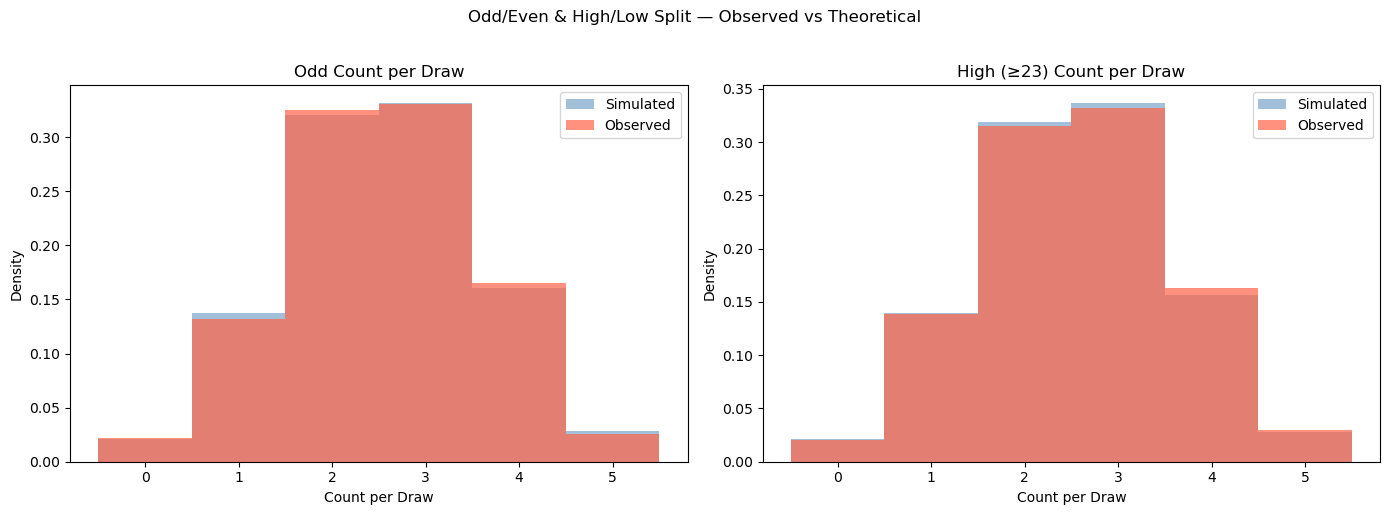

In [22]:
# ── Odd/Even and High/Low per draw ────────────────────────────────
main = df[['n1','n2','n3','n4','n5']]

df['odd_count']  = main.apply(lambda row: sum(x % 2 != 0 for x in row), axis=1)
df['even_count'] = 5 - df['odd_count']
df['high_count'] = main.apply(lambda row: sum(x >= 23 for x in row), axis=1)
df['low_count']  = 5 - df['high_count']

# ── Simulate expected distributions ───────────────────────────────
odd_simulated = np.array([
    sum(x % 2 != 0 for x in np.random.choice(range(1, 46), size=5, replace=False))
    for _ in range(100_000)
])
high_simulated = np.array([
    sum(x >= 23 for x in np.random.choice(range(1, 46), size=5, replace=False))
    for _ in range(100_000)
])

# ── KS tests ──────────────────────────────────────────────────────
ks_odd,  p_odd  = stats.ks_2samp(df['odd_count'].values, odd_simulated)
ks_high, p_high = stats.ks_2samp(df['high_count'].values, high_simulated)

print(f"Odd/Even KS:  stat={ks_odd:.4f},  p={p_odd:.4f}  {'✅' if p_odd  > 0.05 else '❌'}")
print(f"High/Low KS:  stat={ks_high:.4f},  p={p_high:.4f}  {'✅' if p_high > 0.05 else '❌'}")

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, obs, sim, title in zip(
    axes,
    [df['odd_count'].values, df['high_count'].values],
    [odd_simulated, high_simulated],
    ['Odd Count per Draw', 'High (≥23) Count per Draw']
):
    bins = np.arange(-0.5, 6.5, 1)
    ax.hist(sim,  bins=bins, density=True, alpha=0.5, color='steelblue', label='Simulated')
    ax.hist(obs, bins=bins, density=True, alpha=0.7, color='tomato',    label='Observed')
    ax.set_xlabel('Count per Draw')
    ax.set_ylabel('Density')
    ax.set_title(title)
    ax.set_xticks(range(6))
    ax.legend()

plt.suptitle('Odd/Even & High/Low Split — Observed vs Theoretical', y=1.02)
plt.tight_layout()
plt.show()

## 11 · Pairwise Co-occurrence Analysis

Under independence, each of the C(45,2) = 990 number pairs should co-appear with equal expected frequency. A χ² test across all pair counts checks whether any pairs are over- or under-represented.

Expected co-occurrence per pair: 32.61

Pairwise co-occurrence Chi-Square: 910.0260
p-value: 0.9649
Degrees of freedom: 989 (990 pairs)

Verdict: ✅ Pairs consistent with independence

Top 10 most frequent pairs (lift > 1 = appear together more than expected):
 n1  n2  observed  expected     lift
  1  15        48 32.606061 1.472119
  1  34        48 32.606061 1.472119
 12  36        48 32.606061 1.472119
 12  31        47 32.606061 1.441450
 14  29        47 32.606061 1.441450
 23  29        47 32.606061 1.441450
 29  31        47 32.606061 1.441450
  1  41        46 32.606061 1.410781
 13  36        46 32.606061 1.410781
 16  37        46 32.606061 1.410781

Top 10 least frequent pairs:
 n1  n2  observed  expected     lift
 10  22        18 32.606061 0.552045
 22  40        18 32.606061 0.552045
  3  19        19 32.606061 0.582714
 10  20        20 32.606061 0.613383
 16  25        20 32.606061 0.613383
 20  43        20 32.606061 0.613383
  1   2        21 32.606061 0.644052
  1  39

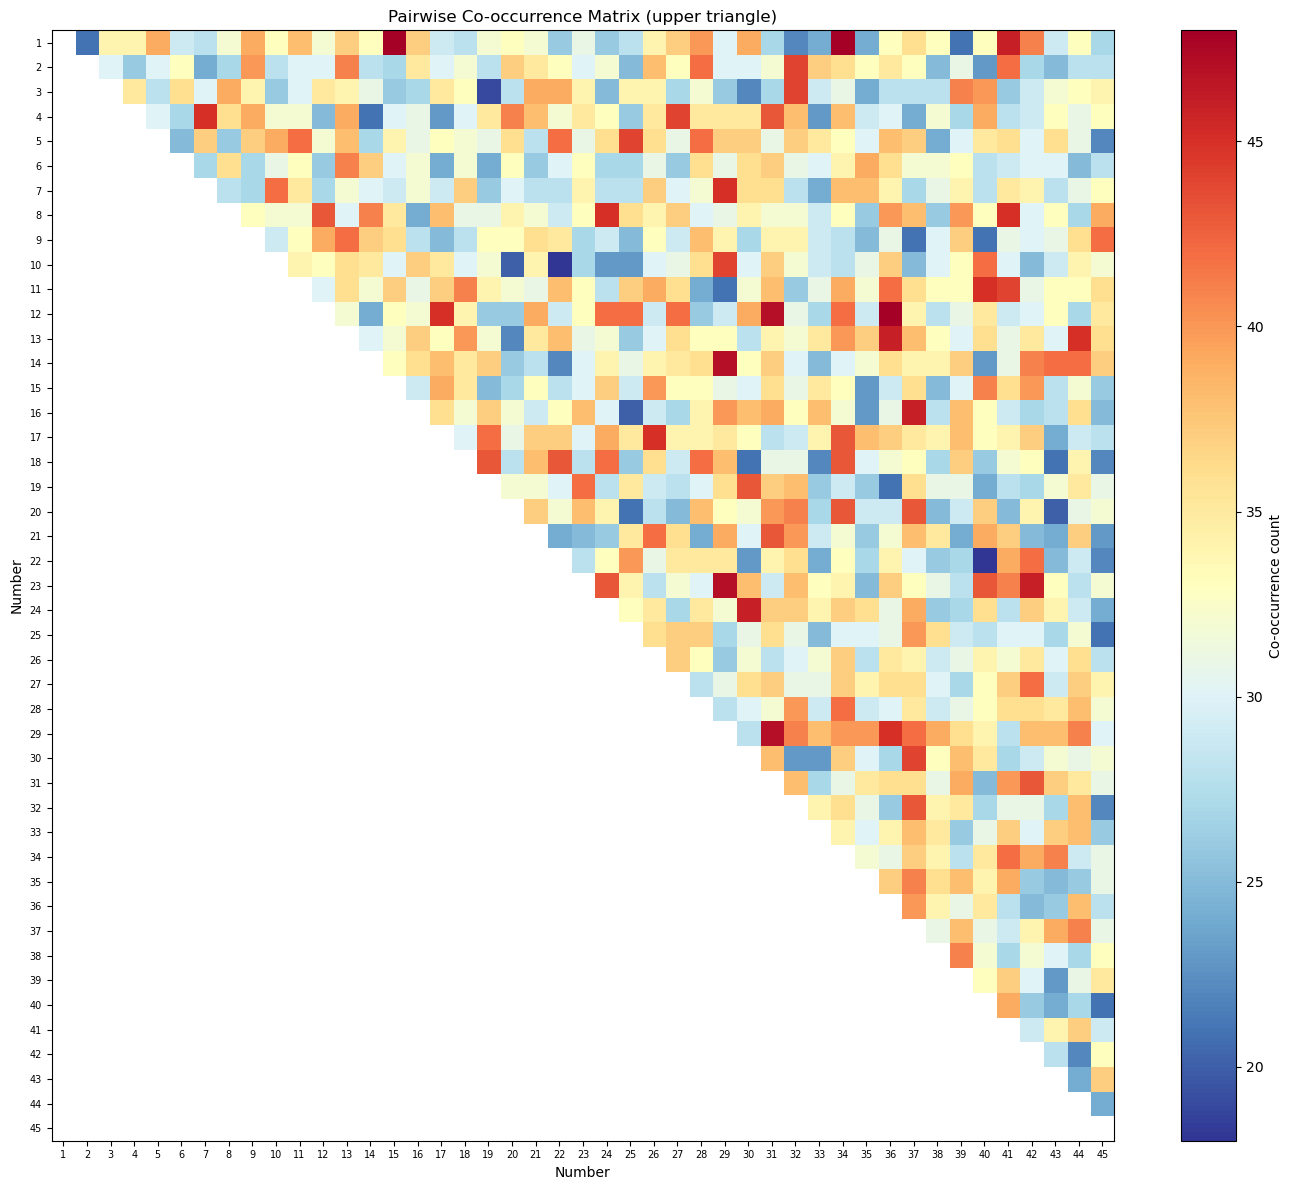

In [23]:
from itertools import combinations

# ── Build co-occurrence matrix ────────────────────────────────────
cooc = np.zeros((45, 45), dtype=int)

for _, row in df.iterrows():
    nums = [row['n1'], row['n2'], row['n3'], row['n4'], row['n5']]
    for i, j in combinations(nums, 2):
        cooc[i-1][j-1] += 1
        cooc[j-1][i-1] += 1

# ── Expected co-occurrence ────────────────────────────────────────
# E = n_draws * C(5,2) / C(45,2) = n_draws * 10/990
n_draws = len(df)
expected_cooc = n_draws * 10 / 990
print(f"Expected co-occurrence per pair: {expected_cooc:.2f}")

# ── Extract upper triangle pairs ──────────────────────────────────
pairs = []
for i, j in combinations(range(1, 46), 2):
    obs = cooc[i-1][j-1]
    lift = obs / expected_cooc
    pairs.append({'n1': i, 'n2': j, 'observed': obs, 
                  'expected': expected_cooc, 'lift': lift})

pairs_df = pd.DataFrame(pairs)

# ── Chi-square on all pair counts ─────────────────────────────────
chi2_pairs, p_pairs = stats.chisquare(
    pairs_df['observed'], 
    f_exp=np.full(len(pairs_df), expected_cooc)
)
print(f"\nPairwise co-occurrence Chi-Square: {chi2_pairs:.4f}")
print(f"p-value: {p_pairs:.4f}")
print(f"Degrees of freedom: {len(pairs_df)-1} (990 pairs)")
print(f"\nVerdict: {'❌ Pairs not independent' if p_pairs < 0.05 else '✅ Pairs consistent with independence'}")

# ── Top overrepresented and underrepresented pairs ────────────────
print(f"\nTop 10 most frequent pairs (lift > 1 = appear together more than expected):")
print(pairs_df.nlargest(10, 'observed')[['n1','n2','observed','expected','lift']].to_string(index=False))

print(f"\nTop 10 least frequent pairs:")
print(pairs_df.nsmallest(10, 'observed')[['n1','n2','observed','expected','lift']].to_string(index=False))

# ── Heatmap ───────────────────────────────────────────────────────
plt.figure(figsize=(14, 12))
mask = np.zeros_like(cooc, dtype=bool)
mask[np.tril_indices_from(mask)] = True
plt.imshow(np.where(mask, np.nan, cooc), cmap='RdYlBu_r', aspect='auto')
plt.colorbar(label='Co-occurrence count')
plt.title('Pairwise Co-occurrence Matrix (upper triangle)')
plt.xlabel('Number')
plt.ylabel('Number')
plt.xticks(range(45), range(1, 46), fontsize=7)
plt.yticks(range(45), range(1, 46), fontsize=7)
plt.tight_layout()
plt.show()

## 12 · Serial Independence — Ljung-Box Autocorrelation Test

A genuine random process should exhibit zero autocorrelation at all lags. We test the time series of draw sums with the Ljung-Box Q-test up to lag 20, and plot ACF/PACF.

Ljung-Box Test on Draw Sums (H0: no autocorrelation):
      lb_stat  lb_pvalue
1    0.095174   0.757699
2    0.348677   0.840013
3    0.402457   0.939734
4    0.644000   0.958051
5    0.647382   0.985731
6    2.579836   0.859428
7    2.589592   0.920201
8    2.855693   0.943084
9    3.720841   0.928807
10   3.736286   0.958460
11   3.823982   0.974786
12   3.875038   0.985587
13   3.891591   0.992291
14   3.959199   0.995707
15   4.229479   0.996884
16   4.404384   0.998010
17   5.488513   0.996016
18   7.561627   0.984473
19  10.708908   0.933242
20  14.607226   0.798424

Any significant lag (p<0.05)? ✅ No


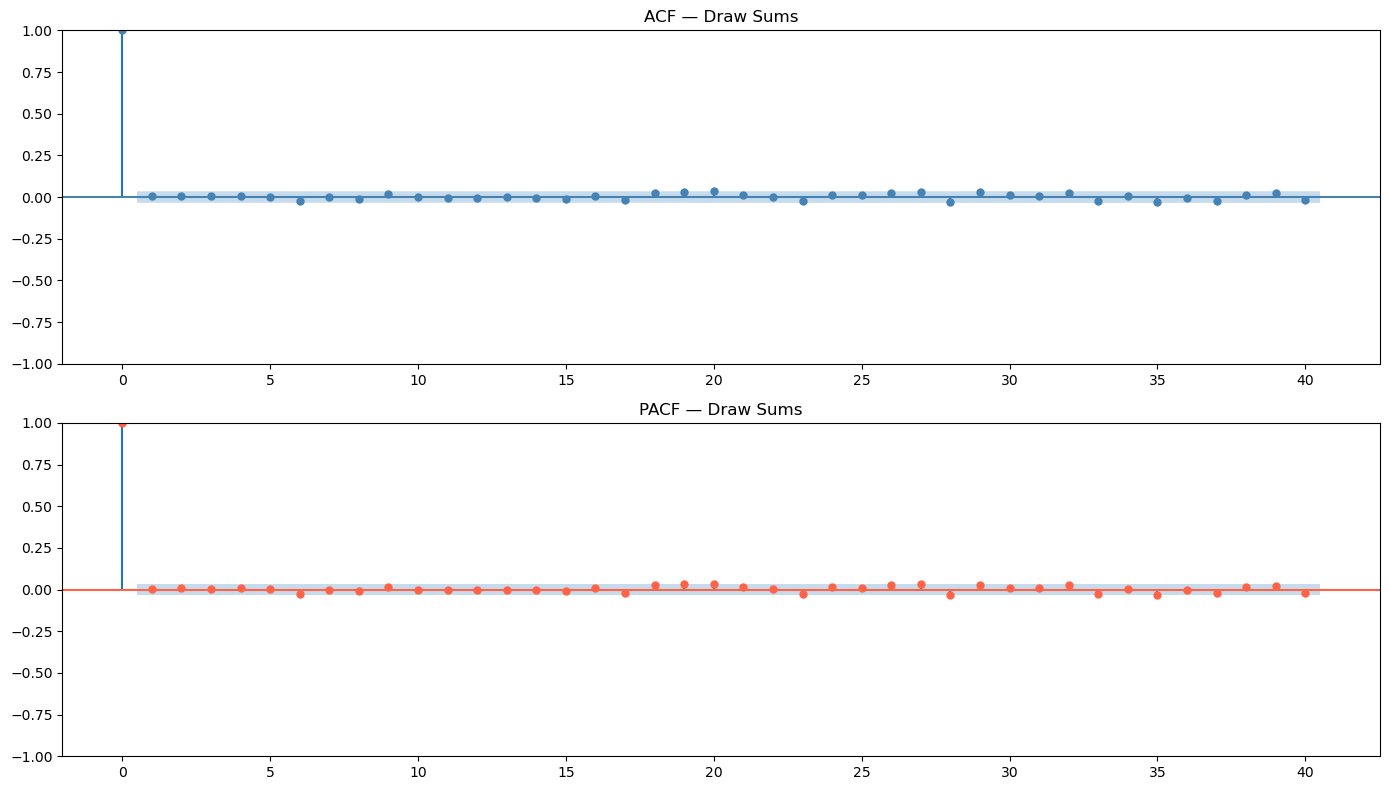

In [24]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# ── Autocorrelation test on draw sums ─────────────────────────────
# if draws are truly independent, the sum time series should show
# zero autocorrelation at all lags
sums = df['draw_id'].map(df.set_index('draw_id')[['n1','n2','n3','n4','n5']].sum(axis=1))
sums = df[['n1','n2','n3','n4','n5']].sum(axis=1).values

# Ljung-Box test — tests for autocorrelation up to lag k
lb_result = acorr_ljungbox(sums, lags=20, return_df=True)
print("Ljung-Box Test on Draw Sums (H0: no autocorrelation):")
print(lb_result.to_string())
print(f"\nAny significant lag (p<0.05)? {'❌ Yes' if (lb_result['lb_pvalue'] < 0.05).any() else '✅ No'}")

# ── Plot ACF manually ─────────────────────────────────────────────
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(sums,  lags=40, ax=axes[0], color='steelblue', title='ACF — Draw Sums')
plot_pacf(sums, lags=40, ax=axes[1], color='tomato',    title='PACF — Draw Sums')
plt.tight_layout()
plt.show()

## 13 · Rolling χ² — Detecting Temporal Drift

A rolling window of 50 consecutive draws tests whether local uniformity ever breaks down over time. Sustained periods above the critical value could indicate a physical change such as ball replacement.

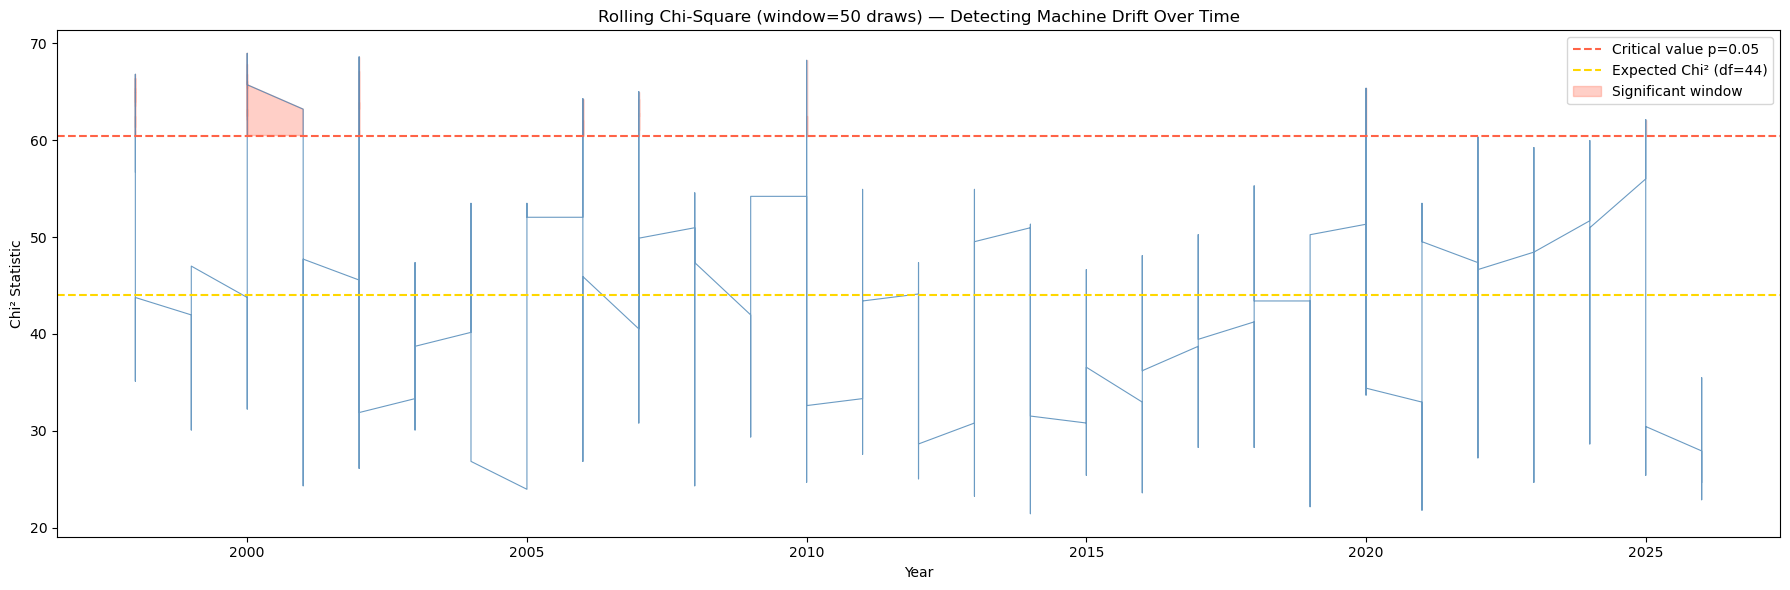

Windows exceeding critical value: 93
Out of total windows: 3179
Rate: 2.9% (expected ~5% by chance)

Year range of significant windows:
  1998 → 2025


In [25]:
# ── Rolling Chi-Square ────────────────────────────────────────────
window = 50  # draws per window
chi2_rolling = []
draw_ids = []

for i in range(window, len(df)+1):
    window_df = df.iloc[i-window:i]
    nums = window_df[['n1','n2','n3','n4','n5']].values.flatten()
    obs  = np.array([np.sum(nums == n) for n in range(1, 46)])
    exp  = np.full(45, len(nums)/45)
    chi2_w, _ = stats.chisquare(obs, exp)
    chi2_rolling.append(chi2_w)
    draw_ids.append(df.iloc[i-1]['draw_id'])

rolling_df = pd.DataFrame({'draw_id': draw_ids, 'chi2': chi2_rolling})

# map draw_id back to year for x-axis labeling
id_to_year = df.set_index('draw_id')['year']
rolling_df['year'] = rolling_df['draw_id'].map(id_to_year)

# ── Plot ──────────────────────────────────────────────────────────
plt.figure(figsize=(18, 6))
plt.plot(rolling_df['year'], rolling_df['chi2'], 
         color='steelblue', linewidth=0.8, alpha=0.8)
plt.axhline(60.48, color='tomato', linestyle='--', 
            linewidth=1.5, label='Critical value p=0.05')
plt.axhline(44.0,  color='gold',   linestyle='--', 
            linewidth=1.5, label='Expected Chi² (df=44)')
plt.fill_between(rolling_df['year'], rolling_df['chi2'], 60.48,
                 where=rolling_df['chi2'] > 60.48,
                 color='tomato', alpha=0.3, label='Significant window')
plt.xlabel('Year')
plt.ylabel('Chi² Statistic')
plt.title(f'Rolling Chi-Square (window={window} draws) — Detecting Machine Drift Over Time')
plt.legend()
plt.tight_layout()
plt.show()

# ── Flag any significant windows ─────────────────────────────────
significant = rolling_df[rolling_df['chi2'] > 60.48]
print(f"Windows exceeding critical value: {len(significant)}")
print(f"Out of total windows: {len(rolling_df)}")
print(f"Rate: {len(significant)/len(rolling_df)*100:.1f}% (expected ~5% by chance)")
if len(significant) > 0:
    print(f"\nYear range of significant windows:")
    print(f"  {significant['year'].min()} → {significant['year'].max()}")

## 14 · Jackpot Outcome Analysis (2003–2024)

From 2003 onwards, each draw record includes ticket sales, the number of jackpot winners, and the prize amount. This section loads and cleans that supplementary data.

In [26]:
jackpot_list = []

for file in all_files:
    year = int(os.path.basename(file).replace('Joker_', '').replace('.xlsx', ''))
    if year < 2003:
        continue

    sheets = pd.read_excel(file, sheet_name=None)

    for sheet_name, temp in sheets.items():
        temp = temp.iloc[3:]  # skip header rows
        temp = temp.iloc[:, [8, 9, 10]]  # tickets_sold, winners, jackpot
        temp.columns = ['tickets_sold', 'winners', 'jackpot']

        # clean Greek number format: remove dots used as thousand separators
        # and replace commas with dots for decimals
        for col in ['tickets_sold', 'winners', 'jackpot']:
            temp[col] = temp[col].astype(str)\
                .str.replace('.', '', regex=False)\
                .str.replace(',', '.', regex=False)\
                .str.strip()
            # replace ΤΖΑΚ-ΠΟΤ (jackpot rollover) with NaN
            temp[col] = temp[col].replace({'ΤΖΑΚΠΟΤ': np.nan, 'ΤΖΑΚ-ΠΟΤ': np.nan, '-': np.nan, 'nan': np.nan})
            temp[col] = pd.to_numeric(temp[col], errors='coerce')

        # drop blank rows
        temp = temp.dropna(subset=['tickets_sold'])
        temp['year'] = year
        jackpot_list.append(temp)

jackpot_df = pd.concat(jackpot_list, ignore_index=True)
jackpot_df = jackpot_df.reset_index(drop=True)

print(jackpot_df.shape)
print(f"\nNull counts:\n{jackpot_df.isnull().sum()}")
print(jackpot_df.head(10))
print(f"\nDraws per year:\n{jackpot_df.groupby('year').size().to_string()}")

(2695, 4)

Null counts:
tickets_sold       0
winners         2255
jackpot         2256
year               0
dtype: int64
   tickets_sold  winners      jackpot  year
0       7217322      NaN          NaN  2003
1      10866036      2.0    1500000.0  2003
2       9128914      NaN          NaN  2003
3       7367010      NaN          NaN  2003
4       7437532      NaN          NaN  2003
5       6570654      NaN          NaN  2003
6       6592132      NaN          NaN  2003
7      18179559      3.0  164620639.0  2003
8      13497186      NaN          NaN  2003
9      10168868      NaN          NaN  2003

Draws per year:
year
2003    103
2004    103
2005    104
2006    103
2007    102
2008    101
2009    103
2010    103
2011    103
2012    103
2013    103
2014    103
2015    104
2016    103
2017    104
2018    103
2019    103
2020    143
2021    155
2022    154
2023    155
2024    156
2025    155
2026     26


c:\Users\makis\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\makis\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [27]:
jackpot_df = jackpot_df.dropna(subset=['tickets_sold'])
jackpot_df = jackpot_df.reset_index(drop=True)

print(jackpot_df.shape)
print(f"\nNull counts:\n{jackpot_df.isnull().sum()}")
print(jackpot_df.head(10))

(2695, 4)

Null counts:
tickets_sold       0
winners         2255
jackpot         2256
year               0
dtype: int64
   tickets_sold  winners      jackpot  year
0       7217322      NaN          NaN  2003
1      10866036      2.0    1500000.0  2003
2       9128914      NaN          NaN  2003
3       7367010      NaN          NaN  2003
4       7437532      NaN          NaN  2003
5       6570654      NaN          NaN  2003
6       6592132      NaN          NaN  2003
7      18179559      3.0  164620639.0  2003
8      13497186      NaN          NaN  2003
9      10168868      NaN          NaN  2003


### 14.1 · Clean & Validate Jackpot Data

In [28]:
total = len(jackpot_df)
has_winner = jackpot_df['winners'].notna().sum()

print(f"Total draws (2003+):         {total}")
print(f"Draws with jackpot winner:   {has_winner} ({has_winner/total*100:.1f}%)")
print(f"Draws without winner:        {total - has_winner} ({(total-has_winner)/total*100:.1f}%)")

print(f"\nWinners per draw (when there is a winner):")
print(jackpot_df['winners'].describe())

print(f"\nJackpot amounts (€):")
print(jackpot_df['jackpot'].describe())

print(f"\nTickets sold:")
print(jackpot_df['tickets_sold'].describe())

print(f"\nDraws per year:")
print(jackpot_df.groupby('year').size().to_string())


# for file in all_files:
#     year = int(os.path.basename(file).replace('Joker_', '').replace('.xlsx', ''))
#     if year < 2003:
#         continue
#     sheets = pd.read_excel(file, sheet_name=None)
#     for sheet_name, temp in sheets.items():
#         print(f"{year} | sheet: {sheet_name} | columns: {temp.shape[1]} | rows: {temp.shape[0]}")

# test_file = [f for f in all_files if 'Joker_2011' in f][0]
# temp = pd.read_excel(test_file)
# print("First 6 rows, all columns:")
# print(temp.head(6).to_string())
# print(f"\nAll column values in row 3 (header row):")
# for i, val in enumerate(temp.iloc[2]):
#     print(f"  col {i}: {val}")

Total draws (2003+):         2695
Draws with jackpot winner:   440 (16.3%)
Draws without winner:        2255 (83.7%)

Winners per draw (when there is a winner):
count    440.00000
mean       1.27500
std        0.86665
min        0.00000
25%        1.00000
50%        1.00000
75%        1.00000
max       10.00000
Name: winners, dtype: float64

Jackpot amounts (€):
count    4.390000e+02
mean     2.092088e+07
std      6.961754e+07
min      2.528557e+05
25%      8.244602e+05
50%      2.002231e+06
75%      4.932663e+06
max      6.902788e+08
Name: jackpot, dtype: float64

Tickets sold:
count    2.695000e+03
mean     4.790639e+06
std      4.561005e+06
min      4.292950e+05
25%      2.748652e+06
50%      3.937766e+06
75%      5.805964e+06
max      8.248955e+07
Name: tickets_sold, dtype: float64

Draws per year:
year
2003    103
2004    103
2005    104
2006    103
2007    102
2008    101
2009    103
2010    103
2011    103
2012    103
2013    103
2014    103
2015    104
2016    103
2017    104
2

### 14.2 · Merge Jackpot Data with Main Draw Records

Both datasets are in chronological order, so we join them positionally within each year. We then derive `had_winner` (boolean) and `p_win_expected` — the theoretical probability of at least one winner given the number of tickets sold.

In [29]:
# ── merge jackpot data with main df ──────────────────────────────
# both are in chronological order so we can merge on position within year
jackpot_df['draw_rank'] = jackpot_df.groupby('year').cumcount()
df['draw_rank'] = df.groupby('year').cumcount()

df_full = df.merge(jackpot_df, on=['year', 'draw_rank'], how='left')
df_full = df_full.drop('draw_rank', axis=1)

print(df_full.shape)
print(df_full.columns.tolist())
print(f"\nNull counts:\n{df_full.isnull().sum()}")

# ── create key analysis columns ───────────────────────────────────
# had_winner: boolean flag
df_full['had_winner'] = df_full['winners'].notna() & (df_full['winners'] > 0)

# expected win probability per draw given tickets sold
# P(at least one winner) = 1 - (1 - 1/24435180)^tickets_sold
JACKPOT_ODDS = 1 / 24_435_180
df_full['p_win_expected'] = 1 - (1 - JACKPOT_ODDS) ** df_full['tickets_sold']

print(f"\nSample of merged data:")
print(df_full[['year', 'draw_id', 'n1','n2','n3','n4','n5','joker',
               'tickets_sold','winners','jackpot','had_winner','p_win_expected']].head(10))

(3228, 15)
['n1', 'n2', 'n3', 'n4', 'n5', 'joker', 'year', 'draw_id', 'odd_count', 'even_count', 'high_count', 'low_count', 'tickets_sold', 'winners', 'jackpot']

Null counts:
n1                 0
n2                 0
n3                 0
n4                 0
n5                 0
joker              0
year               0
draw_id            0
odd_count          0
even_count         0
high_count         0
low_count          0
tickets_sold     533
winners         2788
jackpot         2789
dtype: int64

Sample of merged data:
   year  draw_id  n1  n2  n3  n4  n5  joker  tickets_sold  winners  jackpot  \
0  1997        1  13  34  38  17   4     12           NaN      NaN      NaN   
1  1997        2  32  18  12   5  20      2           NaN      NaN      NaN   
2  1997        3  10  31  11  44  36      8           NaN      NaN      NaN   
3  1997        4  18   6  28  23  35      5           NaN      NaN      NaN   
4  1997        5   5  37  42  11   6      7           NaN      NaN      NaN  

### 14.3 · Restrict to 2003+ and Remove Outliers

99th percentile jackpot: €394,943,065
Rows above 99th percentile: 5

Total draws (2003+): 2695
Draws with winner:   439 (16.3%)
Avg tickets sold:    4,790,639
Avg p(win):          0.1678

TEST 1 — KS test on tickets sold: winner vs non-winner draws
KS stat: 0.2750, p-value: 0.0000
Verdict: ❌ Tickets sold differs — suspicious

TEST 2 — Rollover streak analysis
Total jackpot wins: 439
Avg streak (draws without winner): 5.1
Max streak: 45
Streak distribution:
count    439.000000
mean       5.116173
std        5.478700
min        0.000000
25%        1.000000
50%        4.000000
75%        7.000000
max       45.000000
dtype: float64

KS test vs geometric distribution:
KS stat: 0.1686, p-value: 0.0000
Verdict: ❌ Streaks not geometric — suspicious

TEST 3 — Correlation: win probability vs rollover streak length
Point-biserial correlation: -0.3787, p-value: 0.0000
Verdict: ❌ Wins correlate with streak length — suspicious


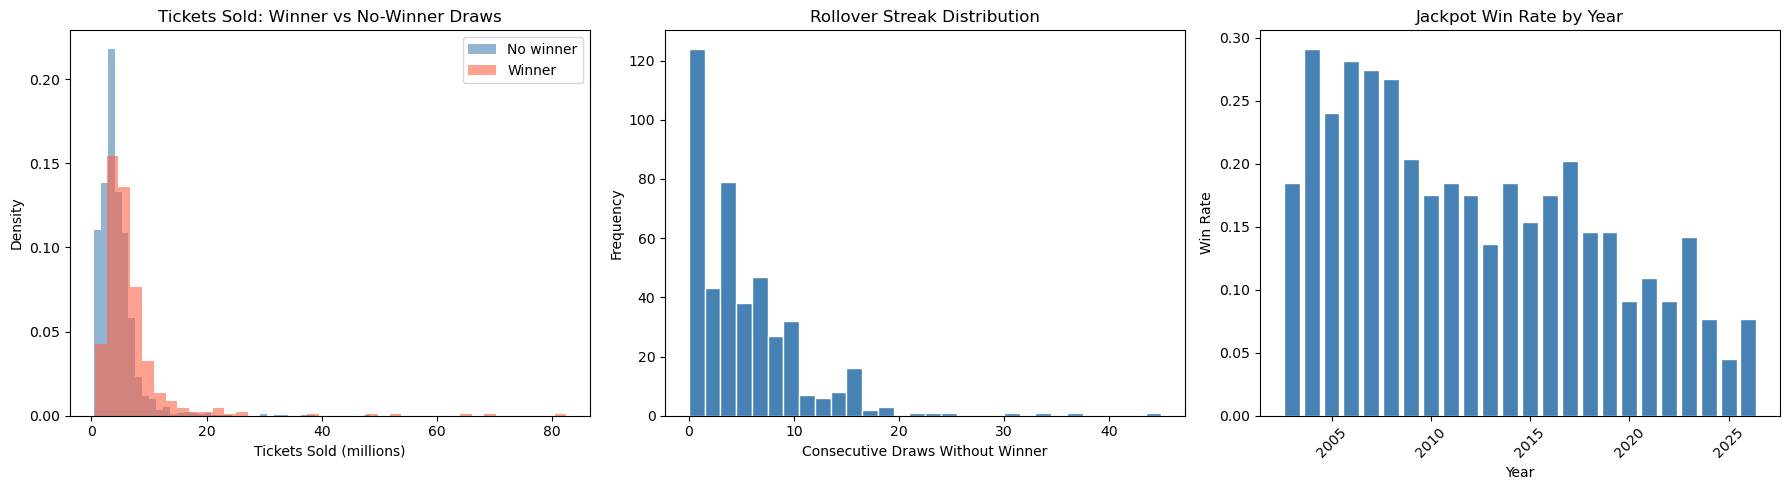

In [30]:
# ── work only with 2003+ where we have jackpot data ──────────────
df_j = df_full[df_full['year'] >= 2003].copy()
df_j = df_j.dropna(subset=['tickets_sold'])

# ── remove the outlier jackpot value ─────────────────────────────
q99 = df_j['jackpot'].quantile(0.99)
print(f"99th percentile jackpot: €{q99:,.0f}")
print(f"Rows above 99th percentile: {(df_j['jackpot'] > q99).sum()}")
df_j.loc[df_j['jackpot'] > q99, 'jackpot'] = np.nan

print(f"\nTotal draws (2003+): {len(df_j)}")
print(f"Draws with winner:   {df_j['had_winner'].sum()} ({df_j['had_winner'].mean()*100:.1f}%)")
print(f"Avg tickets sold:    {df_j['tickets_sold'].mean():,.0f}")
print(f"Avg p(win):          {df_j['p_win_expected'].mean():.4f}")

# ── TEST 1: does win probability correlate with jackpot size? ─────
# if rigged: wins happen more when jackpot is large
df_winners = df_j[df_j['had_winner'] & df_j['jackpot'].notna()]
df_no_winners = df_j[~df_j['had_winner']]

# we need the jackpot size AT THE TIME of each draw
# proxy: cumulative rollover streak → use jackpot amount of winning draw
# or compare tickets_sold between winning and non-winning draws
ks_tickets, p_tickets = stats.ks_2samp(
    df_winners['tickets_sold'].dropna(),
    df_no_winners['tickets_sold'].dropna()
)
print(f"\nTEST 1 — KS test on tickets sold: winner vs non-winner draws")
print(f"KS stat: {ks_tickets:.4f}, p-value: {p_tickets:.4f}")
print(f"Verdict: {'❌ Tickets sold differs — suspicious' if p_tickets < 0.05 else '✅ No significant difference'}")

# ── TEST 2: rollover streak distribution ─────────────────────────
streaks = []
current = 0
for winner in df_j['had_winner']:
    if not winner:
        current += 1
    else:
        streaks.append(current)
        current = 0

streaks = np.array(streaks)
print(f"\nTEST 2 — Rollover streak analysis")
print(f"Total jackpot wins: {len(streaks)}")
print(f"Avg streak (draws without winner): {streaks.mean():.1f}")
print(f"Max streak: {streaks.max()}")
print(f"Streak distribution:")
print(pd.Series(streaks).describe())

# fit geometric distribution
p_geom = 1 / (streaks.mean() + 1)
ks_geom, p_geom_test = stats.kstest(streaks, 'geom', args=(p_geom,))
print(f"\nKS test vs geometric distribution:")
print(f"KS stat: {ks_geom:.4f}, p-value: {p_geom_test:.4f}")
print(f"Verdict: {'❌ Streaks not geometric — suspicious' if p_geom_test < 0.05 else '✅ Streaks consistent with random winning'}")

# ── TEST 3: are wins more likely when jackpot is large? ──────────
# build a running jackpot estimate using rollover streaks
df_j['streak'] = 0
streak = 0
for i in df_j.index:
    if not df_j.loc[i, 'had_winner']:
        streak += 1
    else:
        streak = 0
    df_j.loc[i, 'streak'] = streak

from scipy.stats import pointbiserialr
corr, p_corr = pointbiserialr(df_j['had_winner'].astype(int), df_j['streak'])
print(f"\nTEST 3 — Correlation: win probability vs rollover streak length")
print(f"Point-biserial correlation: {corr:.4f}, p-value: {p_corr:.4f}")
print(f"Verdict: {'❌ Wins correlate with streak length — suspicious' if p_corr < 0.05 else '✅ No correlation between wins and streak length'}")

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# tickets sold: winner vs non-winner
axes[0].hist(df_no_winners['tickets_sold'].dropna()/1e6, bins=40, 
             alpha=0.6, color='steelblue', density=True, label='No winner')
axes[0].hist(df_winners['tickets_sold'].dropna()/1e6, bins=40, 
             alpha=0.6, color='tomato', density=True, label='Winner')
axes[0].set_xlabel('Tickets Sold (millions)')
axes[0].set_ylabel('Density')
axes[0].set_title('Tickets Sold: Winner vs No-Winner Draws')
axes[0].legend()

# streak distribution
axes[1].hist(streaks, bins=30, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Consecutive Draws Without Winner')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Rollover Streak Distribution')

# wins over time
wins_by_year = df_j.groupby('year')['had_winner'].sum()
draws_by_year = df_j.groupby('year').size()
win_rate = wins_by_year / draws_by_year
axes[2].bar(win_rate.index, win_rate.values, color='steelblue', edgecolor='white')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Win Rate')
axes[2].set_title('Jackpot Win Rate by Year')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 14.4 · Calibration Test — Observed vs Expected Wins

The gold-standard fairness check. We compare total observed jackpot wins against the sum of per-draw theoretical win probabilities. A well-calibrated lottery should produce approximately as many winners as the model predicts.

C:\Users\makis\AppData\Local\Temp\ipykernel_12604\1345670842.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = df_j.groupby('p_win_bin').agg(


Observed vs Expected wins per probability bin:
      p_win_bin  total_draws  actual_wins  expected_wins  actual_rate  expected_rate    ratio
(0.0165, 0.112]          758           51      54.155047     0.067282       0.071445 0.941740
 (0.112, 0.207]         1226          190     189.289016     0.154976       0.154396 1.003756
 (0.207, 0.302]          517          123     125.021720     0.237911       0.241822 0.983829
 (0.302, 0.397]          106           38      35.939414     0.358491       0.339051 1.057335
 (0.397, 0.492]           42           15      18.275745     0.357143       0.435137 0.820760
 (0.492, 0.586]           24            9      12.868957     0.375000       0.536207 0.699357
 (0.586, 0.681]            8            6       4.993323     0.750000       0.624165 1.201605
 (0.681, 0.776]            4            0       2.899715     0.000000       0.724929 0.000000
 (0.776, 0.871]            5            2       4.108252     0.400000       0.821650 0.486825
 (0.871, 0.96

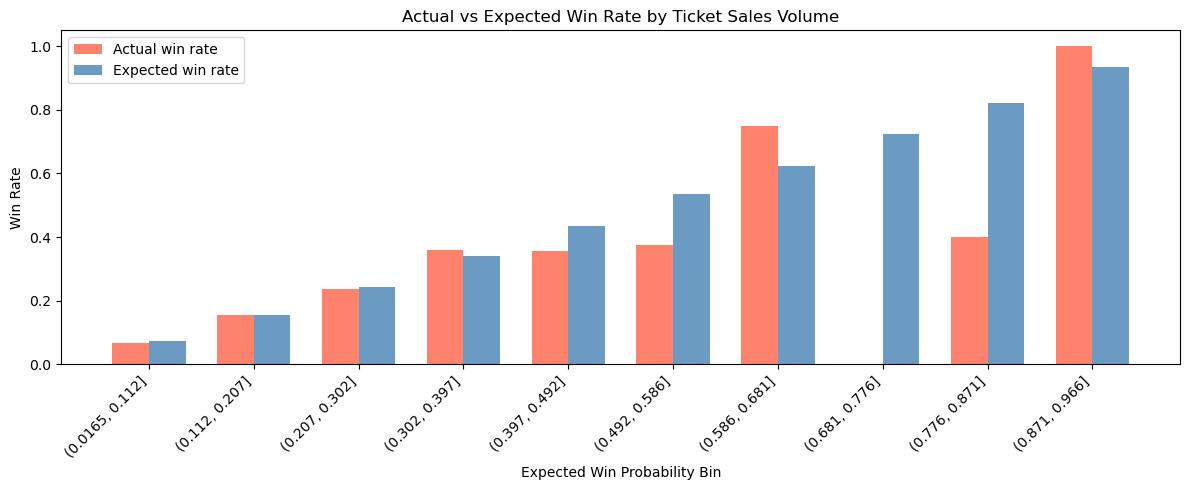

In [31]:
# ── CORRECT TEST: observed wins vs expected wins per draw ─────────
# under fair conditions: P(win) = 1 - (1 - 1/24435180)^tickets_sold
# compare observed win rate vs model-predicted win rate

# bin draws by expected win probability
df_j['p_win_bin'] = pd.cut(df_j['p_win_expected'], bins=10)

binned = df_j.groupby('p_win_bin').agg(
    total_draws    = ('had_winner', 'count'),
    actual_wins    = ('had_winner', 'sum'),
    expected_wins  = ('p_win_expected', 'sum')
).reset_index()

binned['actual_rate']   = binned['actual_wins']   / binned['total_draws']
binned['expected_rate'] = binned['expected_wins']  / binned['total_draws']
binned['ratio']         = binned['actual_wins']    / binned['expected_wins']

print("Observed vs Expected wins per probability bin:")
print(binned[['p_win_bin','total_draws','actual_wins',
              'expected_wins','actual_rate','expected_rate','ratio']].to_string(index=False))

# ── overall calibration test ──────────────────────────────────────
total_expected = df_j['p_win_expected'].sum()
total_actual   = df_j['had_winner'].sum()
print(f"\nTotal expected winners: {total_expected:.1f}")
print(f"Total actual winners:   {total_actual}")
print(f"Ratio actual/expected:  {total_actual/total_expected:.4f}")

# Poisson test: are actual wins consistent with expected?
from scipy.stats import poisson
p_poisson = 1 - poisson.cdf(total_actual - 1, total_expected)
print(f"Poisson p-value:        {p_poisson:.4f}")
print(f"Verdict: {'❌ More wins than expected' if p_poisson < 0.05 else '✅ Wins consistent with ticket sales'}")

# ── Plot: actual vs expected win rate by bin ──────────────────────
plt.figure(figsize=(12, 5))
x = range(len(binned))
width = 0.35
plt.bar([i - width/2 for i in x], binned['actual_rate'],   
        width, color='tomato',    label='Actual win rate',   alpha=0.8)
plt.bar([i + width/2 for i in x], binned['expected_rate'], 
        width, color='steelblue', label='Expected win rate', alpha=0.8)
plt.xticks(x, [str(b) for b in binned['p_win_bin']], rotation=45, ha='right')
plt.xlabel('Expected Win Probability Bin')
plt.ylabel('Win Rate')
plt.title('Actual vs Expected Win Rate by Ticket Sales Volume')
plt.legend()
plt.tight_layout()
plt.show()


# In[ ]: